<a href="https://colab.research.google.com/github/daniellezcanorios/mi-app-streamlit/blob/main/Clasificacion_70_30_Proyecto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de grupo de análisis de material (Clasificación)

LUIS FERNANDO PATIÑO

DANIEL LEZCANO RIOS

1. Preparación de Datos
2. División de los datos 70-30
3. Aprendizaje del Modelo
4. Evaluación del Modelo: matriz de confusion, P,R, ROC
5. Guardar el modelo

* El despliegue se realiza en otro jupyter_notebook

In [ ]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

# 1. Preparación de Datos


In [ ]:
#Cargamos los datos
data = pd.read_excel("resultados_Kmeans_ProyFinal.xlsx", sheet_name="Sheet1")
data.head()

,ID,Unidad Medida,Numero de Transacciones,Cantidad,Reintegros,Precio Unitario,Entrega,Grupo de Analisis
0,0,UN,1,-1.0,0,1750.000,TOTAL,0
1,1,UN,1,-10.0,0,754.000,TOTAL,0
2,2,UN,1,-91.0,0,290.000,PARCIAL,1
3,3,UN,5,-18.0,0,5332.334,TOTAL,0
4,4,UN,9,-50.0,0,11136.050,TOTAL,0


In [ ]:
#Conocemos los datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2345 entries, 0 to 2344
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2345 non-null   int64  
 1   Unidad Medida            2345 non-null   object 
 2   Numero de Transacciones  2345 non-null   int64  
 3   Cantidad                 2345 non-null   float64
 4   Reintegros               2345 non-null   int64  
 5   Precio Unitario          2345 non-null   float64
 6   Entrega                  2345 non-null   object 
 7   Grupo de Analisis        2345 non-null   int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 146.7+ KB


In [ ]:
# Eliminar variables que no se usarán en el modelo
data = data.drop(columns=['ID'])

In [ ]:
# Se define valores categóricos a los Clusters
mapeo_clusters = {0:'Normal UN', 1:'Crítico Mayor', 2:'Normal ML', 3:'Normal KG', 4:'Crítico Reintegro', 5:'Crítico ML', 6:'Normal LT'}
data['Grupo de Analisis'] = data['Grupo de Analisis'].map(mapeo_clusters)
print(data['Grupo de Analisis'].unique())
data.head()

['Normal UN' 'Crítico Mayor' 'Crítico Reintegro' 'Normal LT' 'Normal KG'
 'Normal ML' 'Crítico ML']


,Unidad Medida,Numero de Transacciones,Cantidad,Reintegros,Precio Unitario,Entrega,Grupo de Analisis
0,UN,1,-1.0,0,1750.000,TOTAL,Normal UN
1,UN,1,-10.0,0,754.000,TOTAL,Normal UN
2,UN,1,-91.0,0,290.000,PARCIAL,Crítico Mayor
3,UN,5,-18.0,0,5332.334,TOTAL,Normal UN
4,UN,9,-50.0,0,11136.050,TOTAL,Normal UN


In [ ]:
#Corrección tipos de datos
data['Unidad Medida']=data['Unidad Medida'].astype('category')
data['Entrega']=data['Entrega'].astype('category')
data['Grupo de Analisis']=data['Grupo de Analisis'].astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2345 entries, 0 to 2344
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Unidad Medida            2345 non-null   category
 1   Numero de Transacciones  2345 non-null   int64   
 2   Cantidad                 2345 non-null   float64 
 3   Reintegros               2345 non-null   int64   
 4   Precio Unitario          2345 non-null   float64 
 5   Entrega                  2345 non-null   category
 6   Grupo de Analisis        2345 non-null   category
dtypes: category(3), float64(2), int64(2)
memory usage: 81.0 KB


In [ ]:
#Descripción de variables numéricas
data.describe()

,Numero de Transacciones,Cantidad,Reintegros,Precio Unitario
count,2345.000000,2345.000000,2345.000000,2.345000e+03
mean,2.664392,-88.101691,7.572708,1.627424e+06
std,4.912497,921.917954,197.535027,8.628105e+06
min,1.000000,-28612.000000,0.000000,8.940000e+00
25%,1.000000,-15.000000,0.000000,1.183276e+04
50%,1.000000,-4.000000,0.000000,6.783000e+04
75%,3.000000,-1.000000,0.000000,6.051800e+05
max,131.000000,0.000000,8640.000000,3.003104e+08


<Axes: >

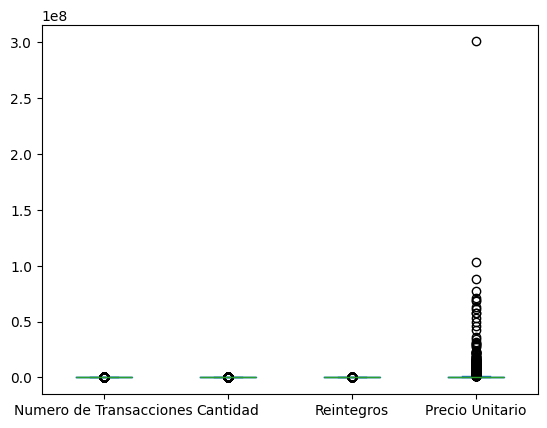

In [ ]:
#Descripción variables numéricas
data.plot(kind='box')

<Axes: xlabel='Unidad Medida'>

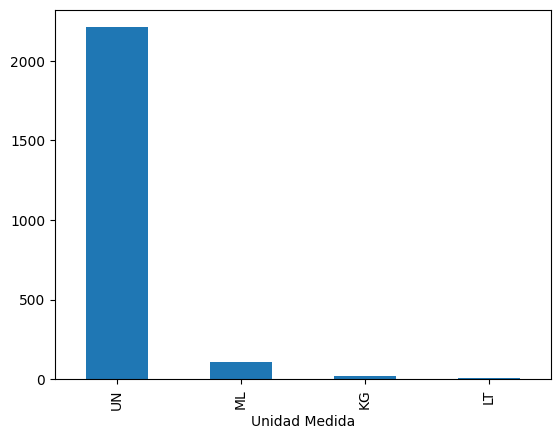

In [ ]:
#Descripción variables categóricas
data['Unidad Medida'].value_counts().plot(kind='bar')

<Axes: xlabel='Entrega'>

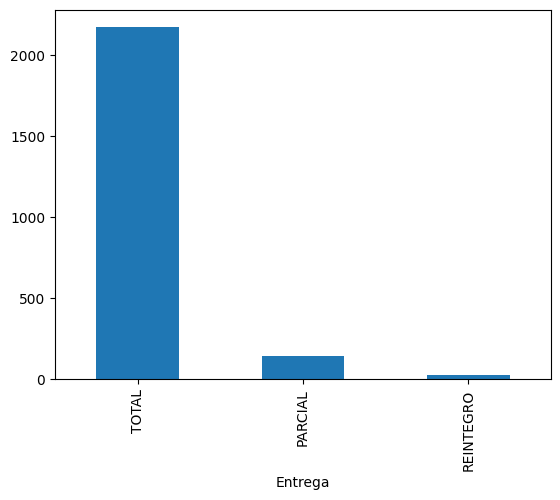

In [ ]:
#Descripción variables categóricas
data['Entrega'].value_counts().plot(kind='bar')

<Axes: xlabel='Grupo de Analisis'>

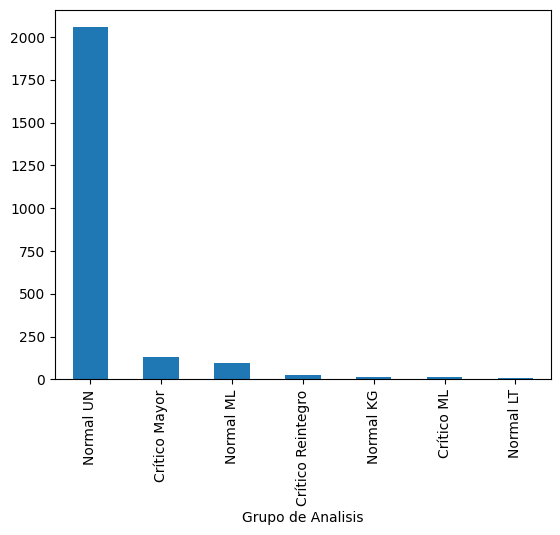

In [ ]:
#Descripción variables categóricas
data['Grupo de Analisis'].value_counts().plot(kind='bar')

# 2. División 70-30

In [ ]:
# División 70 - 30:
from sklearn.model_selection import train_test_split
# Definimos X (predictoras) y Y (objetivo) desde el DataFrame original
X = data.drop("Grupo de Analisis", axis=1)
Y = data["Grupo de Analisis"]
# Dividimos Stratify=Y para mantener las 7 clases en ambos grupos.
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.30,
    random_state=42,
    stratify=Y
)
print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")

Entrenamiento: 1641 muestras
Prueba: 704 muestras


Axes(0.125,0.11;0.775x0.77)


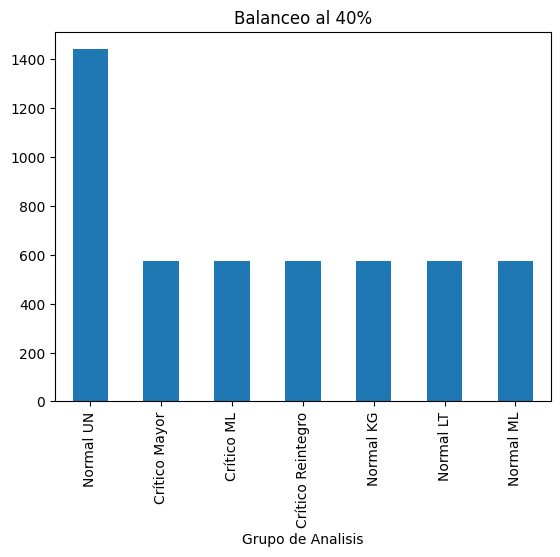

In [ ]:
# Balanceo: Los grupos minoritarios tendrán el 40% del tamaño del grupo mayoritario, adicionando datos sintéticos (Solo al grupo de entrenamiento):
from imblearn.over_sampling import SMOTENC
# Identificar índices de categorías en el set de entrenamiento
cat_idx = [i for i, col in enumerate(X_train.columns) if X_train[col].dtype.name == 'category']
# Definir la estrategia del 40% basada solo en y_train
conteo_train = y_train.value_counts()
n_target = int(conteo_train.max() * 0.4)
estrategia = {clase: max(n, n_target) for clase, n in conteo_train.items()}
# Aplicar SMOTENC
smote_nc = SMOTENC(categorical_features=cat_idx, sampling_strategy=estrategia, k_neighbors=3, random_state=42)
X_train_res, y_train_res = smote_nc.fit_resample(X_train, y_train)
print(y_train_res.value_counts().plot(kind='bar', title='Balanceo al 40%'))

In [ ]:
# Codificación de variables categóricas:
from sklearn.preprocessing import LabelEncoder
X_train_encoded = X_train_res.copy()
X_test_encoded = X_test.copy()
le = LabelEncoder()
# Lista de columnas con texto en X
cols_categoricas = ['Unidad Medida', 'Entrega']

for col in cols_categoricas:
    X_train_encoded[col] = le.fit_transform(X_train_res[col])
    X_test_encoded[col] = le.transform(X_test[col])

In [ ]:
# Instalar pandas profiling

!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 4.5 MB/s eta 0:00:00


In [ ]:
# Cargar librería para Profiling
from pandas_profiling import ProfileReport

profile_data=ProfileReport(X_train_encoded, minimal=False) # minimal=True
profile_data

/tmp/ipykernel_11280/343286192.py:2: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 6/6 [00:00<00:00, 38.39it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
#Guardamos en html el perfilado de datos (Informe)
profile_data.to_file(output_file="output.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# 3. Aprendizaje con el 70% y Evaluación con el 30%

# **Tree**
No se normaliza

In [ ]:
# Entrenamiento árbol:
from sklearn.tree import DecisionTreeClassifier
# Mejorando los parámetros del Árbol
modelTree = DecisionTreeClassifier(
    criterion='gini',           # El motor de decisión
    max_depth=8,               # Limitamos la profundidad para evitar overfitting
    min_samples_split=20,       # No permite crear ramas para casos muy aislados
    min_samples_leaf=10,        # Cada hoja final debe tener al menos 10 registros
    random_state=42
)

modelTree.fit(X_train_encoded, y_train_res)


DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

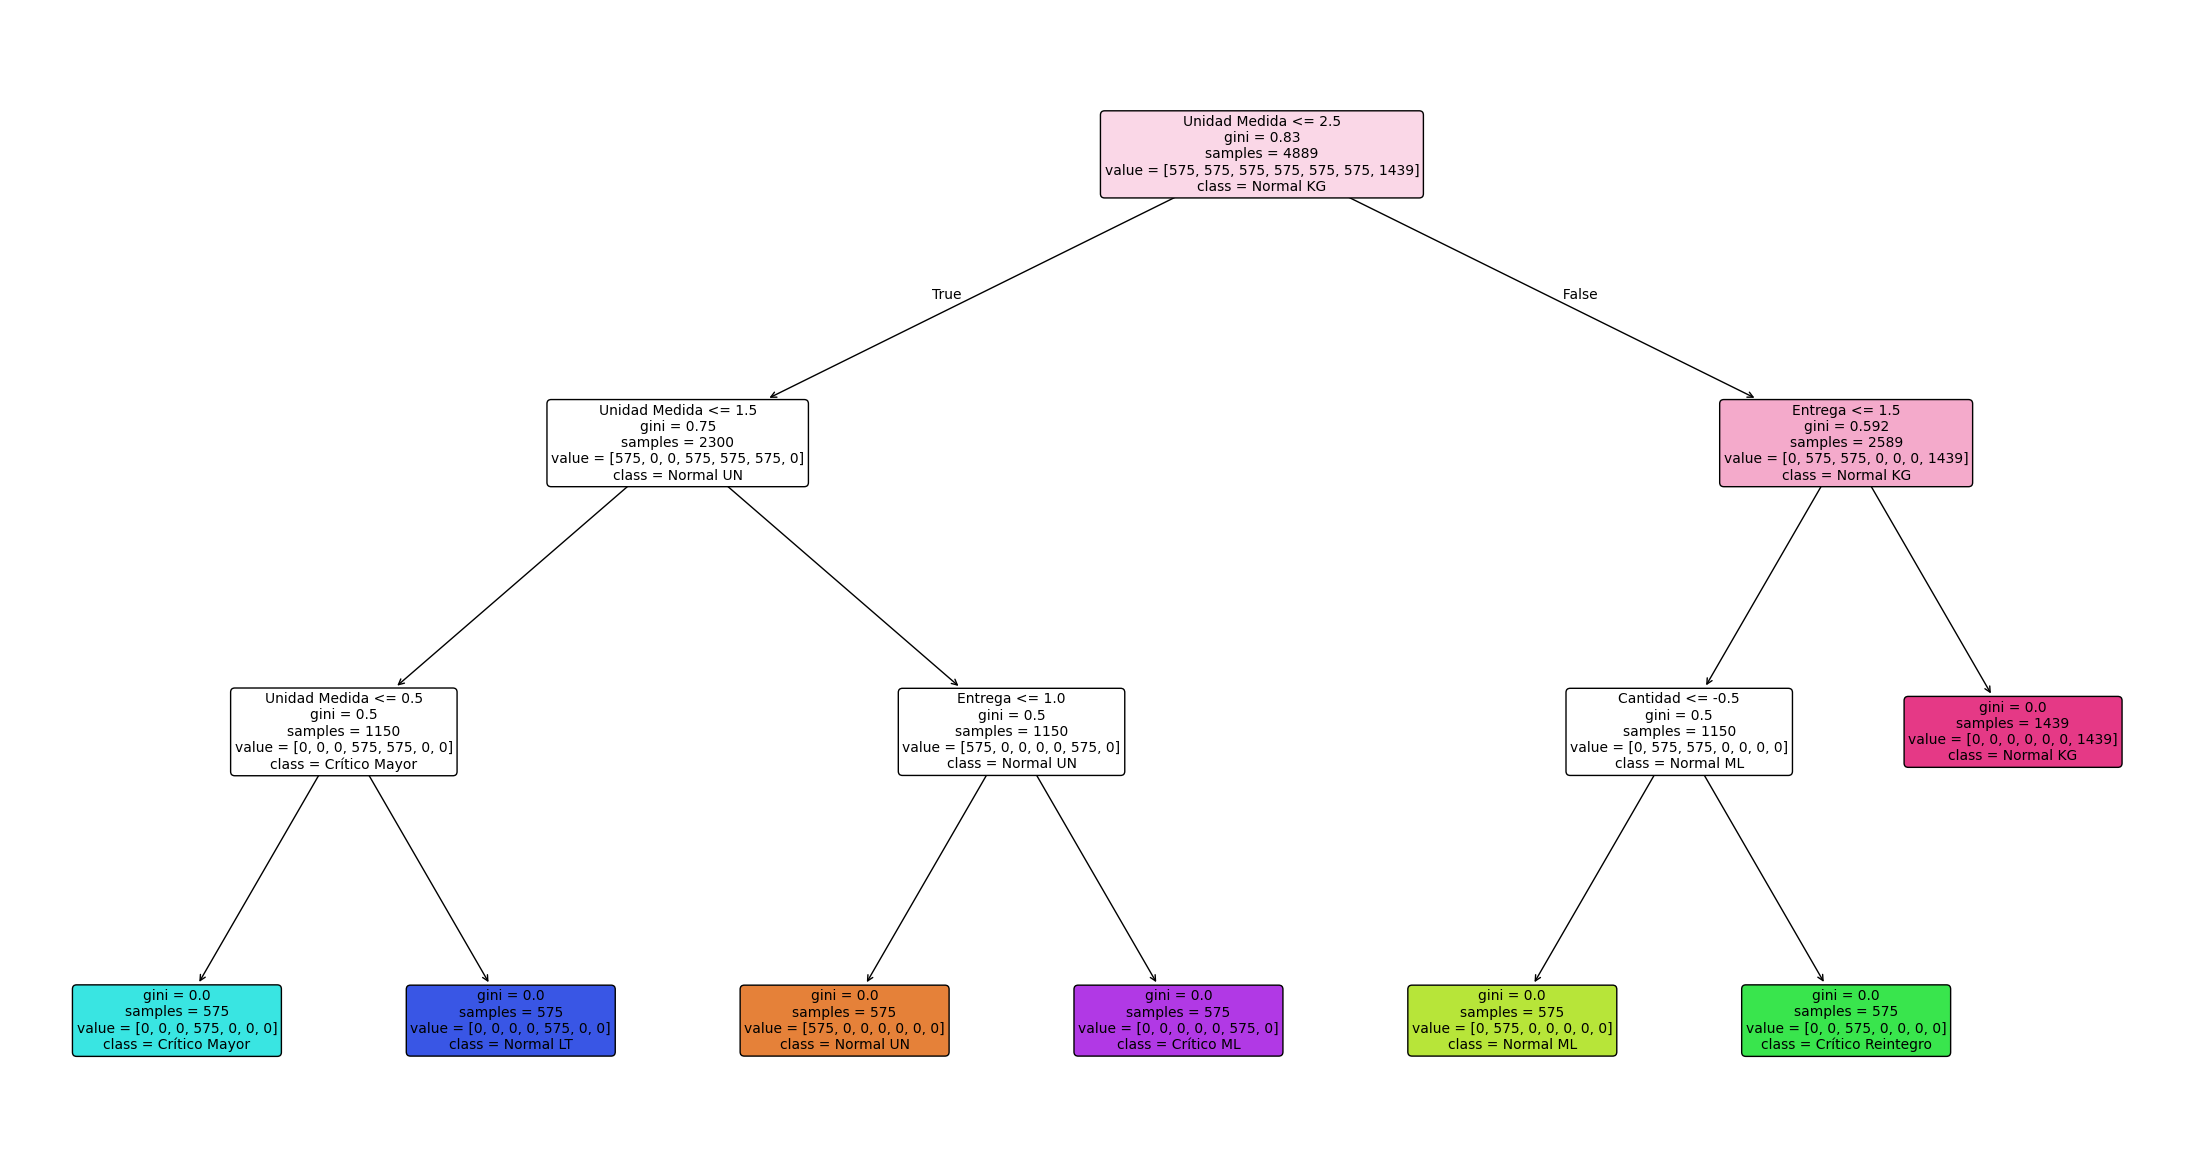

<function matplotlib.pyplot.show(close=None, block=None)>

In [ ]:
# Graficar árbol
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
# Configurar el tamaño de la imagen
plt.figure(figsize=(28, 15))
# class_names: extraemos los valores únicos de y_train convertidos a lista de strings
plot_tree(modelTree,
          feature_names=X_train.columns.values,
          class_names=list(map(str, y_train.unique())),
          rounded=True,
          filled=True,
          fontsize=10)
# Mostrar el gráfico
plt.show()
plt.show


# 4. Evaluación del Modelo Árbol de Decisión

Exactitud del modelo: 99.43%


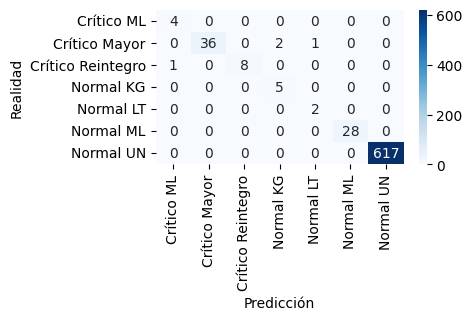


Reporte de Clasificación:
                   precision    recall  f1-score   support

       Crítico ML       0.80      1.00      0.89         4
    Crítico Mayor       1.00      0.92      0.96        39
Crítico Reintegro       1.00      0.89      0.94         9
        Normal KG       0.71      1.00      0.83         5
        Normal LT       0.67      1.00      0.80         2
        Normal ML       1.00      1.00      1.00        28
        Normal UN       1.00      1.00      1.00       617

         accuracy                           0.99       704
        macro avg       0.88      0.97      0.92       704
     weighted avg       1.00      0.99      0.99       704



In [ ]:
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

# Realizar la predicción usando el set de prueba CODIFICADO
y_pred = modelTree.predict(X_test_encoded)

# Calcular la exactitud (Accuracy)
exactitud = metrics.accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {exactitud:.2%}")

# Matriz de Confusión para las 7 categorías
# Obtener las clases ordenadas alfabéticamente
clases_ordenadas = sorted(y_test.unique())
# Generar la matriz
matriz = metrics.confusion_matrix(y_test, y_pred, labels=clases_ordenadas)
# Graficar con las etiquetas correctas
plt.figure(figsize=(4, 2))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=clases_ordenadas,
            yticklabels=clases_ordenadas)
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()

# Reporte detallado (Precision, Recall, F1-score)
print("\nReporte de Clasificación:")
print(metrics.classification_report(y_test, y_pred))

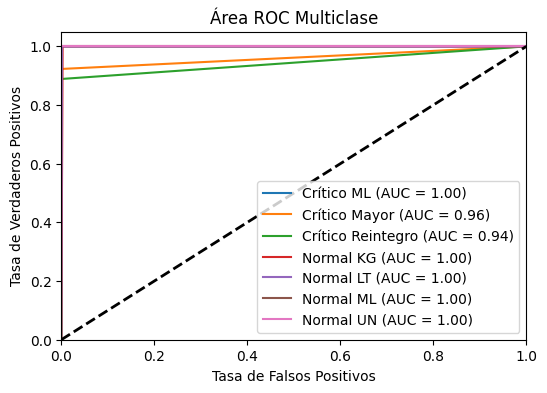

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Definir las clases en ORDEN ALFABÉTICO
clases_ordenadas = sorted(y_test.unique())
# Binarizar las etiquetas
y_test_bin = label_binarize(y_test, classes=clases_ordenadas)
n_classes = len(clases_ordenadas)
# Obtener probabilidades (X_test_encoded debe ser el de tu set de prueba)
y_score = modelTree.predict_proba(X_test_encoded)
# Calcular y graficar
plt.figure(figsize=(6, 4))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{clases_ordenadas[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Área ROC Multiclase')
plt.legend(loc="lower right")
plt.show()

# **KNN**          K Vecinos más Cercanos
* Normalización (Porque es un modelo basado en distancias, entonces se debe tener variables numéricas y normalizadas para que estén en los mismos rangos de valores

In [ ]:
# KNN K Vecinos más Cercanos
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, roc_auc_score

X_train_np = np.nan_to_num(X_train_encoded.values)
X_test_np = np.nan_to_num(X_test_encoded.values)

# Escalar o normalizar
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np)

# Configuración del modelo
from sklearn.neighbors import KNeighborsClassifier
modelKnn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

# Entrenar y Predecir
modelKnn.fit(X_train_scaled, y_train_res)
y_pred = modelKnn.predict(X_test_scaled)
y_probs = modelKnn.predict_proba(X_test_scaled)

# Mostrar Resultados
print("--- Reporte de Clasificación KNN ---")
print(classification_report(y_test, y_pred))

# Valor del Área ROC (Multiclase)
auc_val = roc_auc_score(y_test, y_probs, multi_class='ovr')
print(f"\nValor Área ROC (AUC): {auc_val:.4f}")

--- Reporte de Clasificación KNN ---
                   precision    recall  f1-score   support

       Crítico ML       0.50      0.75      0.60         4
    Crítico Mayor       0.97      0.92      0.95        39
Crítico Reintegro       1.00      1.00      1.00         9
        Normal KG       1.00      1.00      1.00         5
        Normal LT       1.00      1.00      1.00         2
        Normal ML       1.00      1.00      1.00        28
        Normal UN       1.00      1.00      1.00       617

         accuracy                           0.99       704
        macro avg       0.92      0.95      0.94       704
     weighted avg       1.00      0.99      0.99       704


Valor Área ROC (AUC): 0.9941


ValueError: The number of FixedLocator locations (7), usually from a call to set_ticks, does not match the number of labels (3).

<Figure size 600x400 with 0 Axes>

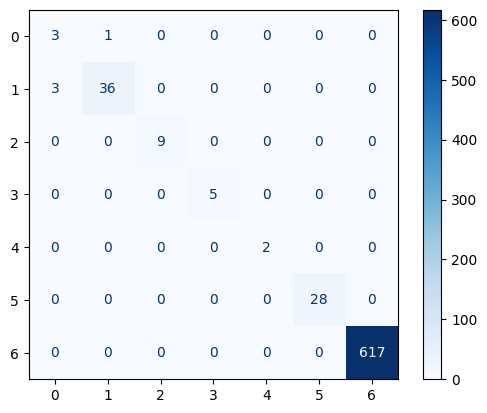

In [ ]:
# Matriz de confusión
# Evaluación de Knn con 30%
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculamos la matriz usando los valores reales y las predicciones
cm = confusion_matrix(y_test, y_pred)

# La graficamos
plt.figure(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

# Personalización visual
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - Modelo KNN')
plt.xticks(rotation=45)
plt.show()